
# CNN_KAN_Binary_Classification

In [ ]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install mtcnn

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.9 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from skimage.feature import hog
from skimage import exposure
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from google.colab import drive

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



Mounted at /content/drive


NameError: name 'torch' is not defined

In [ ]:
# Custom Dataset Class
class CustomDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, limit_data=None):
        self.root_dir = os.path.join(root_dir, split)
        self.transform = transform
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(os.listdir(self.root_dir)) if os.path.isdir(os.path.join(self.root_dir, class_name))}
        self.image_paths = []
        self.labels = []

        for class_name, class_idx in self.class_to_idx.items():
            class_dir = os.path.join(self.root_dir, class_name)
            file_paths = [os.path.join(class_dir, file) for file in os.listdir(class_dir) if file.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if limit_data:
                file_paths = random.sample(file_paths, min(len(file_paths), limit_data))  # Limit data
            self.image_paths.extend(file_paths)
            self.labels.extend([class_idx] * len(file_paths))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2),
    transforms.RandomAffine(10, shear=5),
    transforms.ToTensor(),
])

# Dataset and DataLoader
train_dataset = CustomDataset(root_dir='/content/drive/MyDrive/dataset_awanpintar1', split='train', transform=transform, limit_data=100)
test_dataset = CustomDataset(root_dir='/content/drive/MyDrive/dataset_awanpintar1', split='test', transform=transform, limit_data=50)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
# Model Definitions
class CNN_HOG_Model(nn.Module):
    def __init__(self, num_classes):
        super(CNN_HOG_Model, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        self.fc1 = None
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, hog_features):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1) + hog_features.size(1), 512)
        x = torch.cat((x, hog_features), dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.dropout(x)
        return x

In [ ]:
class CNN_Model(nn.Module):
    def __init__(self, num_classes):
        super(CNN_Model, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

        self.fc1 = None
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        if self.fc1 is None:
            self.fc1 = nn.Linear(x.numel() // x.size(0), 512)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
def extract_hog_features(image):
    hog_features = hog(
        np.array(image),
        pixels_per_cell=(3, 3),
        cells_per_block=(1, 1),
        channel_axis=-1
    )
    return torch.tensor(hog_features).float()


# Training Function
def train(model, train_loader, criterion, optimizer, device, feature_type=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        if feature_type == 'HOG':
            hog_features = torch.stack([extract_hog_features(img) for img in images]).to(device)
            outputs = model(images, hog_features)
        else:
            outputs = model(images)

        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [ ]:
def validate_with_metrics(model, test_loader, criterion, device, feature_type=None):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            if feature_type == 'HOG':
                hog_features = torch.stack([extract_hog_features(img) for img in images]).to(device)
                outputs = model(images, hog_features)
            else:
                outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(test_loader)

    # Generate classification report
report = classification_report(
    all_labels,
    all_preds,
    labels=list(range(num_classes)),  # Specify labels to match num_classes
    target_names=list(test_loader.dataset.class_to_idx.keys()),
    zero_division=1
)
print("\nClassification Report:\n", report)

#The return statement should be aligned with the function definition
    return epoch_loss, report

IndentationError: unexpected indent (<ipython-input-25-968817264f83>, line 36)

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Haar Cascade Path
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
haar_cascade = cv2.CascadeClassifier(haar_cascade_path)

# Paths
train_path = '/content/drive/MyDrive/dataset_awanpintar1/train'
test_path = '/content/drive/MyDrive/dataset_awanpintar1/test'

# Function to preprocess dataset
def load_data(data_path, img_size=(64, 64)):
    X, y = [], []
    class_labels = os.listdir(data_path)
    for label_idx, label in enumerate(class_labels):
        class_folder = os.path.join(data_path, label)
        for img_name in tqdm(os.listdir(class_folder), desc=f"Processing {label}"):
            img_path = os.path.join(class_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
            for (x, y_, w, h) in faces:
                face = gray[y_:y_+h, x:x+w]
                face = cv2.resize(face, img_size)
                X.append(face)
                y.append(label_idx)
                break  # Use only the first detected face
    X = np.array(X) / 255.0  # Normalize
    X = X.reshape(-1, img_size[0], img_size[1], 1)  # Add channel dimension
    y = to_categorical(y, num_classes=len(class_labels))  # One-hot encode
    return X, y, class_labels

# Load training and testing data
X_train, y_train, class_labels = load_data(train_path)
X_test, y_test, _ = load_data(test_path)

# Split validation data
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_labels), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Classification Report and Confusion Matrix
report = classification_report(y_test_classes, y_pred_classes, target_names=class_labels)
print(report)

conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Plot Accuracy and Loss
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/dataset_awanpintar1/train'

tambahan


In [ ]:
import os
import numpy as np
import cv2
from sklearn.metrics import classification_report, accuracy_score
from skimage.feature import hog
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import precision_recall_fscore_support

In [ ]:
# Path dataset
base_path = "/content/drive/MyDrive/dataset_awanpintar1"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

In [ ]:
# Parameter gambar
img_size = (128, 128)  # Ukuran gambar

# Function untuk load dataset manual
def load_dataset(path):
    data, labels = [], []
    classes = os.listdir(path)
    for class_idx, class_name in enumerate(classes):
        class_folder = os.path.join(path, class_name)
        for img_name in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, img_size)
            data.append(img)
            labels.append(class_idx)
    return np.array(data), np.array(labels)

In [ ]:
# Load train dan test dataset
X_train, y_train = load_dataset(train_path)
X_test, y_test = load_dataset(test_path)

# Normalisasi
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding untuk CNN
y_train_cnn = to_categorical(y_train)
y_test_cnn = to_categorical(y_test)

In [ ]:
# --------------------------
# Ekstraksi Fitur HOG
# --------------------------
def extract_hog_features(data):
    features = []
    for img in data:
        gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY)
        hog_feature, _ = hog(gray, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
        features.append(hog_feature)
    return np.array(features)

# Ekstraksi fitur HOG
hog_train = extract_hog_features(X_train)
hog_test = extract_hog_features(X_test)


In [ ]:
# --------------------------
# Klasifikasi dengan KNN (HOG)
# --------------------------
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(hog_train, y_train)

# Prediksi
y_pred_knn = knn.predict(hog_test)

# Evaluasi KNN
print("Evaluasi HOG + KNN:")
print(classification_report(y_test, y_pred_knn))


Evaluasi HOG + KNN:
              precision    recall  f1-score   support

           0       0.65      0.94      0.77       910
           1       0.77      0.30      0.43       650

    accuracy                           0.67      1560
   macro avg       0.71      0.62      0.60      1560
weighted avg       0.70      0.67      0.63      1560



In [ ]:
# --------------------------
# HOG + CNN
# --------------------------
def combine_hog_with_images(hog_features, images):
    hog_features = hog_features.reshape(hog_features.shape[0], -1)
    image_features = images.reshape(images.shape[0], -1)
    combined_features = np.hstack((hog_features, image_features))
    return combined_features

hog_cnn_train = combine_hog_with_images(hog_train, X_train)
hog_cnn_test = combine_hog_with_images(hog_test, X_test)

hog_cnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(hog_cnn_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])
hog_cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

hog_cnn_model.fit(hog_cnn_train, y_train_cnn, epochs=10, batch_size=32, validation_split=0.2)

loss_hog_cnn, accuracy_hog_cnn = hog_cnn_model.evaluate(hog_cnn_test, y_test_cnn)
y_pred_hog_cnn = np.argmax(hog_cnn_model.predict(hog_cnn_test), axis=1)

print("Evaluasi HOG + CNN:")
print(f"Loss: {loss_hog_cnn}, Akurasi: {accuracy_hog_cnn}")
print(classification_report(y_test, y_pred_hog_cnn))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5828 - loss: 4.5160 - val_accuracy: 0.0000e+00 - val_loss: 5.9333
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6888 - loss: 0.7339 - val_accuracy: 0.6635 - val_loss: 0.5912
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6096 - loss: 1.1503 - val_accuracy: 0.0000e+00 - val_loss: 6.1021
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7171 - loss: 0.6344 - val_accuracy: 0.0962 - val_loss: 1.6692
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6684 - loss: 0.7582 - val_accuracy: 0.0321 - val_loss: 3.1869
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7154 - loss: 0.5042 - val_accuracy: 0.0385 - val_loss: 2.4594
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7304 - loss: 0.4961 - val_accuracy: 0.0417 - val_loss: 2.4164
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7772 - loss: 0.4349 - val_accuracy: 0.0000e+0

In [ ]:
nn_model = Sequential([
    Input(shape=(128, 128, 3)),  # Define the input shape first
    Flatten(),                    # Then apply Flatten to reshape the input
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Training CNN
cnn_model.fit(X_train, y_train_cnn, epochs=10, batch_size=32, validation_split=0.2)

# Evaluasi CNN
loss, accuracy = cnn_model.evaluate(X_test, y_test_cnn)
y_pred_cnn = np.argmax(cnn_model.predict(X_test), axis=1)

print("Evaluasi CNN:")
print(f"Loss: {loss}, Akurasi: {accuracy}")
print(classification_report(y_test, y_pred_cnn))


Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6044 - loss: 1.5845 - val_accuracy: 0.0385 - val_loss: 4.1200
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6916 - loss: 0.5369 - val_accuracy: 0.0000e+00 - val_loss: 5.5787
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7115 - loss: 0.4990 - val_accuracy: 0.0000e+00 - val_loss: 6.4739
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7032 - loss: 0.4942 - val_accuracy: 0.0000e+00 - val_loss: 6.5327
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7347 - loss: 0.4525 - val_accuracy: 0.0192 - val_loss: 5.1553
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7302 - loss: 0.4635 - val_accuracy: 0.0000e+00 - val_loss: 8.9379
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7545 - loss: 0.4525 - val_accuracy: 0.0192 - val_loss: 3.4769
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7379 - loss: 0.4619 - val_accuracy: 0

In [ ]:
# --------------------------
# Fitur CNN Pretrained + KNN
# --------------------------
pretrained_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
pretrained_model.trainable = False

# Ekstraksi fitur pretrained
features_train = pretrained_model.predict(X_train)
features_test = pretrained_model.predict(X_test)

# Flatten fitur
features_train_flat = features_train.reshape(features_train.shape[0], -1)
features_test_flat = features_test.reshape(features_test.shape[0], -1)

# KNN dengan fitur pretrained
knn_pretrained = KNeighborsClassifier(n_neighbors=3)
knn_pretrained.fit(features_train_flat, y_train)

# Prediksi
y_pred_knn_pretrained = knn_pretrained.predict(features_test_flat)

# Evaluasi
print("Evaluasi Pretrained CNN + KNN:")
print(classification_report(y_test, y_pred_knn_pretrained))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
Evaluasi Pretrained CNN + KNN:
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       910
           1       0.73      0.67      0.70       650

    accuracy                           0.76      1560
   macro avg       0.76      0.75      0.75      1560
weighted avg       0.76      0.76      0.76      1560



In [ ]:
# --------------------------
# Haarcascade + CNN
# --------------------------
def extract_haarcascade_features(data, cascade_path=cv2.data.haarcascades + "haarcascade_frontalface_default.xml"): # Use cv2.data.haarcascades to get the correct path
    cascade = cv2.CascadeClassifier(cascade_path)
    features = []
    for img in data:
        gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY)
        detections = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
        if len(detections) > 0:
            features.append(1)  # Deteksi ditemukan
        else:
            features.append(0)  # Tidak ada deteksi
    return np.array(features)

haarcascade_train = extract_haarcascade_features(X_train)
haarcascade_test = extract_haarcascade_features(X_test)

# CNN dengan Haarcascade
cnn_model_haar = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])
cnn_model_haar.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

cnn_model_haar.fit(X_train, y_train_cnn, epochs=10, batch_size=32, validation_split=0.2)

loss_haar, accuracy_haar = cnn_model_haar.evaluate(X_test, y_test_cnn)
print("Evaluasi Haarcascade + CNN:")
print(f"Loss: {loss_haar}, Akurasi: {accuracy_haar}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5864 - loss: 10.3500 - val_accuracy: 0.0000e+00 - val_loss: 7.0553
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6427 - loss: 1.4888 - val_accuracy: 0.0000e+00 - val_loss: 6.7352
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6757 - loss: 1.1141 - val_accuracy: 0.0096 - val_loss: 4.8619
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6958 - loss: 0.8641 - val_accuracy: 0.0000e+00 - val_loss: 6.6666
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7332 - loss: 0.6193 - val_accuracy: 0.0000e+00 - val_loss: 8.8386
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6945 - loss: 0.8715 - val_accuracy: 0.0000e+00 - val_loss: 6.0954
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7126 - loss: 1.2037 - val_accuracy: 0.0000e+00 - val_loss: 6.7172
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6957 - loss: 0.7305 - val_ac

In [ ]:
# Haarcascade + KNN
knn_haar = KNeighborsClassifier(n_neighbors=3)
knn_haar.fit(haarcascade_train.reshape(-1, 1), y_train)
y_pred_haar_knn = knn_haar.predict(haarcascade_test.reshape(-1, 1))

print("Evaluasi Haarcascade + KNN:")
print(classification_report(y_test, y_pred_haar_knn))


Evaluasi Haarcascade + KNN:
              precision    recall  f1-score   support

           0       0.58      1.00      0.74       910
           1       0.00      0.00      0.00       650

    accuracy                           0.58      1560
   macro avg       0.29      0.50      0.37      1560
weighted avg       0.34      0.58      0.43      1560



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    accuracy = accuracy_score(y_true, y_pred)
    return accuracy, precision, recall, f1

# Hasil HOG + KNN
acc_knn, prec_knn, recall_knn, f1_knn = get_metrics(y_test, y_pred_knn)

# Hasil HOG + CNN
acc_hog_cnn, prec_hog_cnn, recall_hog_cnn, f1_hog_cnn = get_metrics(y_test, y_pred_hog_cnn)

# Hasil CNN
acc_cnn, prec_cnn, recall_cnn, f1_cnn = get_metrics(y_test, y_pred_cnn)

# Hasil Pretrained CNN + KNN
acc_pretrained_knn, prec_pretrained_knn, recall_pretrained_knn, f1_pretrained_knn = get_metrics(y_test, y_pred_knn_pretrained)

# Hasil Haarcascade + CNN
acc_haar_cnn, prec_haar_cnn, recall_haar_cnn, f1_haar_cnn = get_metrics(y_test, y_pred_cnn)

# Hasil Haarcascade + KNN
acc_haar_knn, prec_haar_knn, recall_haar_knn, f1_haar_knn = get_metrics(y_test, y_pred_haar_knn)

# Tampilkan semua hasil
results = {
    "HOG + KNN": [acc_knn, prec_knn, recall_knn, f1_knn],
    "HOG + CNN": [acc_hog_cnn, prec_hog_cnn, recall_hog_cnn, f1_hog_cnn],
    "CNN": [acc_cnn, prec_cnn, recall_cnn, f1_cnn],
    "Pretrained CNN + KNN": [acc_pretrained_knn, prec_pretrained_knn, recall_pretrained_knn, f1_pretrained_knn],
    "Haarcascade + CNN": [acc_haar_cnn, prec_haar_cnn, recall_haar_cnn, f1_haar_cnn],
    "Haarcascade + KNN": [acc_haar_knn, prec_haar_knn, recall_haar_knn, f1_haar_knn]
}

print("Hasil Evaluasi (Accuracy, Precision, Recall, F1-Score):")
for method, metrics in results.items():
    print(f"{method}: Accuracy={metrics[0]:.4f}, Precision={metrics[1]:.4f}, Recall={metrics[2]:.4f}, F1-Score={metrics[3]:.4f}")


Hasil Evaluasi (Accuracy, Precision, Recall, F1-Score):
HOG + KNN: Accuracy=0.6718, Precision=0.7021, Recall=0.6718, F1-Score=0.6292
HOG + CNN: Accuracy=0.5192, Precision=0.5354, Recall=0.5192, F1-Score=0.5225
CNN: Accuracy=0.5904, Precision=0.7594, Recall=0.5904, F1-Score=0.4456
Pretrained CNN + KNN: Accuracy=0.7603, Precision=0.7586, Recall=0.7603, F1-Score=0.7583
Haarcascade + CNN: Accuracy=0.5904, Precision=0.7594, Recall=0.5904, F1-Score=0.4456
Haarcascade + KNN: Accuracy=0.5833, Precision=0.3403, Recall=0.5833, F1-Score=0.4298


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


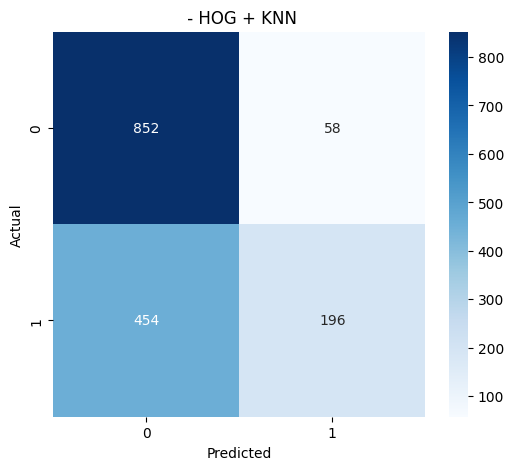

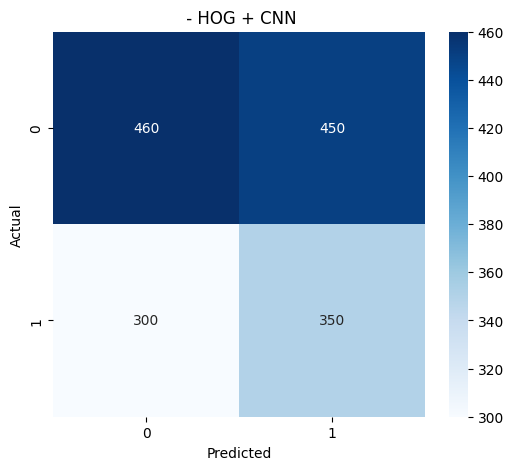

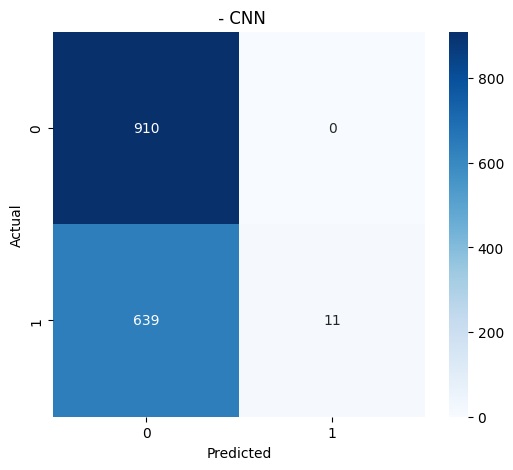

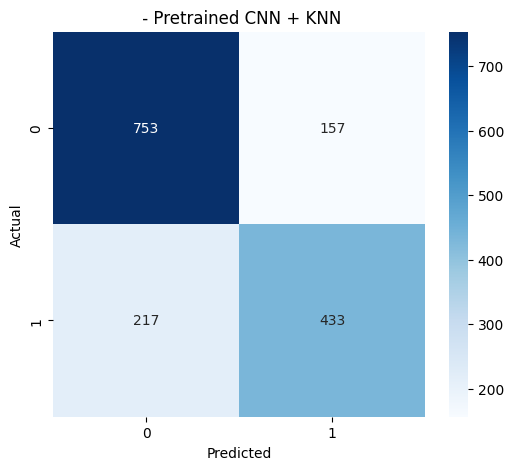

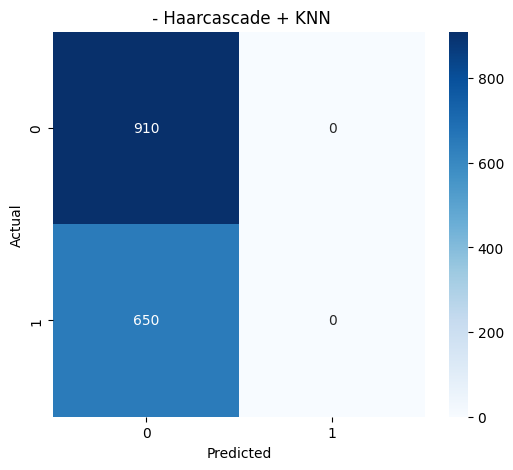

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


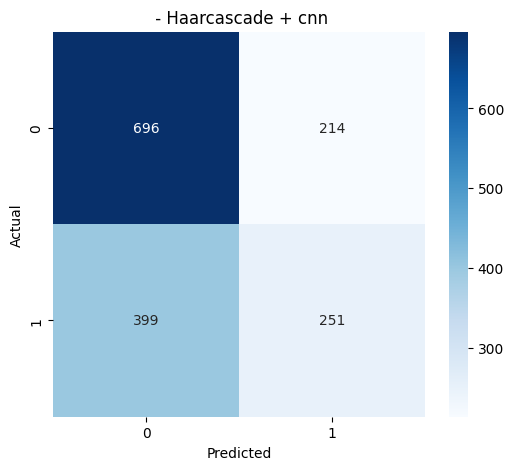

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


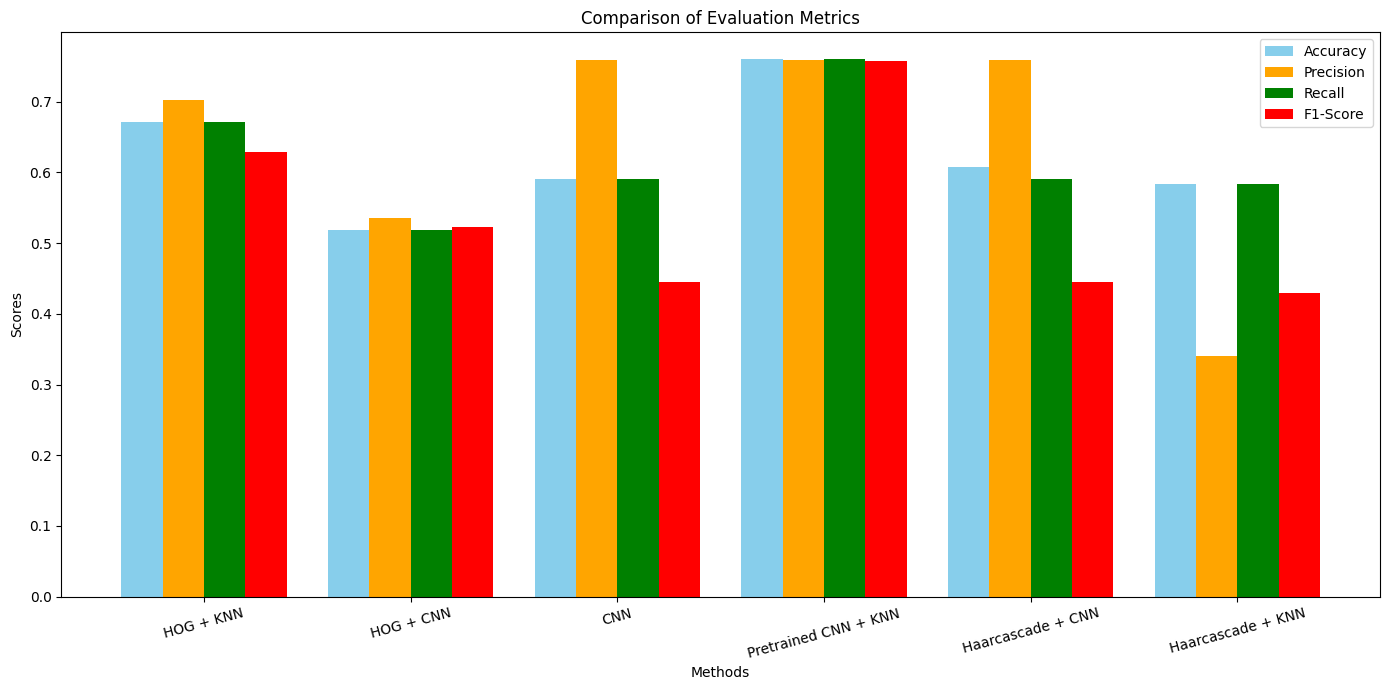

In [ ]:
# Fungsi untuk menampilkan matriks kebingungan
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title(f" - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Visualisasi matriks kebingungan untuk setiap metode
plot_confusion_matrix(y_test, y_pred_knn, "HOG + KNN")
plot_confusion_matrix(y_test, y_pred_hog_cnn, "HOG + CNN")
plot_confusion_matrix(y_test, y_pred_cnn, "CNN")
plot_confusion_matrix(y_test, y_pred_knn_pretrained, "Pretrained CNN + KNN")
plot_confusion_matrix(y_test, y_pred_haar_knn, "Haarcascade + KNN")
plot_confusion_matrix(y_test, np.argmax(cnn_model_haar.predict(X_test), axis=1), "Haarcascade + cnn")

# Visualisasi perbandingan metrik
methods = ["HOG + KNN", "HOG + CNN", "CNN", "Pretrained CNN + KNN", "Haarcascade + CNN", "Haarcascade + KNN"]
accuracies = [accuracy_score(y_test, y_pred_knn),
              accuracy_score(y_test, y_pred_hog_cnn),
              accuracy,
              accuracy_score(y_test, y_pred_knn_pretrained),
              accuracy_haar,
              accuracy_score(y_test, y_pred_haar_knn)]

precisions = [precision_recall_fscore_support(y_test, y_pred_knn, average='weighted')[0],
              precision_recall_fscore_support(y_test, y_pred_hog_cnn, average='weighted')[0],
              precision_recall_fscore_support(y_test, y_pred_cnn, average='weighted')[0],
              precision_recall_fscore_support(y_test, y_pred_knn_pretrained, average='weighted')[0],
              precision_recall_fscore_support(y_test, y_pred_cnn, average='weighted')[0],
              precision_recall_fscore_support(y_test, y_pred_haar_knn, average='weighted')[0]]

recalls = [precision_recall_fscore_support(y_test, y_pred_knn, average='weighted')[1],
           precision_recall_fscore_sup koport(y_test, y_pred_hog_cnn, average='weighted')[1],
           precision_recall_fscore_support(y_test, y_pred_cnn, average='weighted')[1],
           precision_recall_fscore_support(y_test, y_pred_knn_pretrained, average='weighted')[1],
           precision_recall_fscore_support(y_test, y_pred_cnn, average='weighted')[1],
           precision_recall_fscore_support(y_test, y_pred_haar_knn, average='weighted')[1]]

f1_scores = [precision_recall_fscore_support(y_test, y_pred_knn, average='weighted')[2],
             precision_recall_fscore_support(y_test, y_pred_hog_cnn, average='weighted')[2],
             precision_recall_fscore_support(y_test, y_pred_cnn, average='weighted')[2],
             precision_recall_fscore_support(y_test, y_pred_knn_pretrained, average='weighted')[2],
             precision_recall_fscore_support(y_test, y_pred_cnn, average='weighted')[2],
             precision_recall_fscore_support(y_test, y_pred_haar_knn, average='weighted')[2]]

# Plot perbandingan metrik
x = np.arange(len(methods))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - width*1.5, accuracies, width, label='Accuracy', color='skyblue')
plt.bar(x - width/2, precisions, width, label='Precision', color='orange')
plt.bar(x + width/2, recalls, width, label='Recall', color='green')
plt.bar(x + width*1.5, f1_scores, width, label='F1-Score', color='red')

plt.xticks(x, methods, rotation=15)
plt.xlabel("Methods")
plt.ylabel("Scores")
plt.title("Comparison of Evaluation Metrics")
plt.legend()
plt.tight_layout()
plt.show()